# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

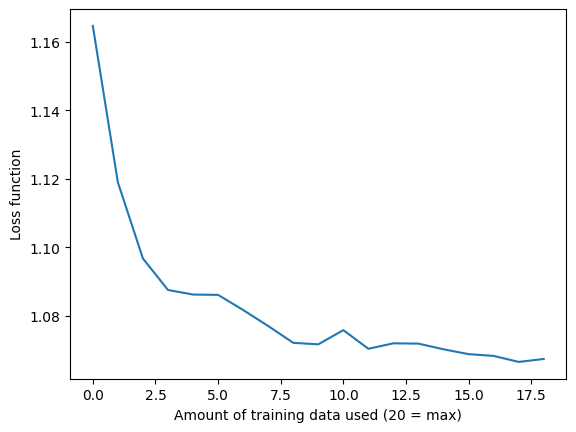

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

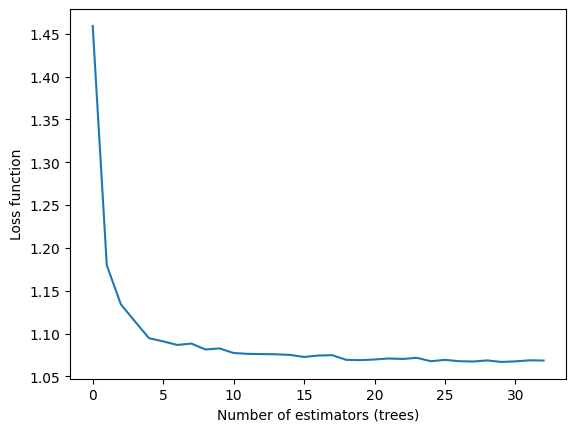

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# answer
I would keep plot 1 because it shows a meaninful realtinship between training data size and model performance. The leveling off pattern is actionable. I cut plot 2 because the gradual improvement from more trees is unremarkable and doesnt add much insight. The x axis should have data used because it matters more. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

## Approach

This week I apply the modeling techniques from Week 10 — Random Forest, cross-validation, hyperparameter tuning, and performance metrics — to two of my real logistics/supply-chain datasets:

1. **Logistics Supply Chain** (`logistics_supply.csv`) — Predicting `shipping_costs` using the same 6 features from my Week 9 linear regression analysis, so I can directly compare RF vs. LR performance.
2. **FAF5 Freight** (`faf5.csv`) — Predicting `tons_2024` freight volume using transport mode, origin/destination, commodity type, and lag features from prior years.

For each dataset I will:
- Fit a baseline Random Forest with default parameters
- Use `RandomizedSearchCV` with 5-fold cross-validation to tune hyperparameters
- Evaluate with RMSE and R² metrics
- Visualize feature importances and actual-vs-predicted plots

## Analysis 1: Logistics Supply Chain — Predicting Shipping Costs with Random Forest

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import randint

# ── Load data and select features ─────────────────────────────────────────────
df_logistics = pd.read_csv('datasets/logistics_supply.csv')

features = [
    'loading_unloading_time',
    'customs_clearance_time',
    'eta_variation_hours',
    'traffic_congestion_level',
    'fuel_consumption_rate',
    'delivery_time_deviation',
]
target = 'shipping_costs'

df_model = df_logistics[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Features: {features}")
print(f"Target: {target}")

Train size: 25,652  |  Test size: 6,413
Features: ['loading_unloading_time', 'customs_clearance_time', 'eta_variation_hours', 'traffic_congestion_level', 'fuel_consumption_rate', 'delivery_time_deviation']
Target: shipping_costs


In [8]:
# ── Baseline Random Forest (default parameters) ──────────────────────────────
np.random.seed(42)
rf_baseline = RandomForestRegressor(random_state=42)
rf_baseline.fit(X_train, y_train)

pred_baseline = rf_baseline.predict(X_test)
rmse_baseline = root_mean_squared_error(pred_baseline, y_test)
r2_baseline = r2_score(y_test, pred_baseline)

print("=== Baseline Random Forest (defaults) ===")
print(f"  Test RMSE: {rmse_baseline:.4f}")
print(f"  Test R²:   {r2_baseline:.4f}")
print(f"  Parameters: n_estimators={rf_baseline.n_estimators}, max_depth={rf_baseline.max_depth}")

=== Baseline Random Forest (defaults) ===
  Test RMSE: 315.6127
  Test R²:   -0.0308
  Parameters: n_estimators=100, max_depth=None


In [9]:
# ── RandomizedSearchCV: Hyperparameter Tuning ─────────────────────────────────
np.random.seed(42)

param_distributions = {
    "n_estimators": [10, 33, 100, 200],
    "max_depth": [4, 8, 16, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
}

rcv = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
)
rcv.fit(X_train, y_train)

pred_tuned = rcv.predict(X_test)
rmse_tuned = root_mean_squared_error(pred_tuned, y_test)
r2_tuned = r2_score(y_test, pred_tuned)

print("=== Tuned Random Forest (RandomizedSearchCV) ===")
print(f"  Best parameters: {rcv.best_params_}")
print(f"  Best CV score (neg RMSE): {rcv.best_score_:.4f}")
print(f"  Test RMSE: {rmse_tuned:.4f}")
print(f"  Test R²:   {r2_tuned:.4f}")
print()
print("=== Comparison ===")
print(f"  Baseline RF  — RMSE: {rmse_baseline:.4f}, R²: {r2_baseline:.4f}")
print(f"  Tuned RF     — RMSE: {rmse_tuned:.4f}, R²: {r2_tuned:.4f}")

=== Tuned Random Forest (RandomizedSearchCV) ===
  Best parameters: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 100}
  Best CV score (neg RMSE): -312.6121
  Test RMSE: 310.9190
  Test R²:   -0.0003

=== Comparison ===
  Baseline RF  — RMSE: 315.6127, R²: -0.0308
  Tuned RF     — RMSE: 310.9190, R²: -0.0003


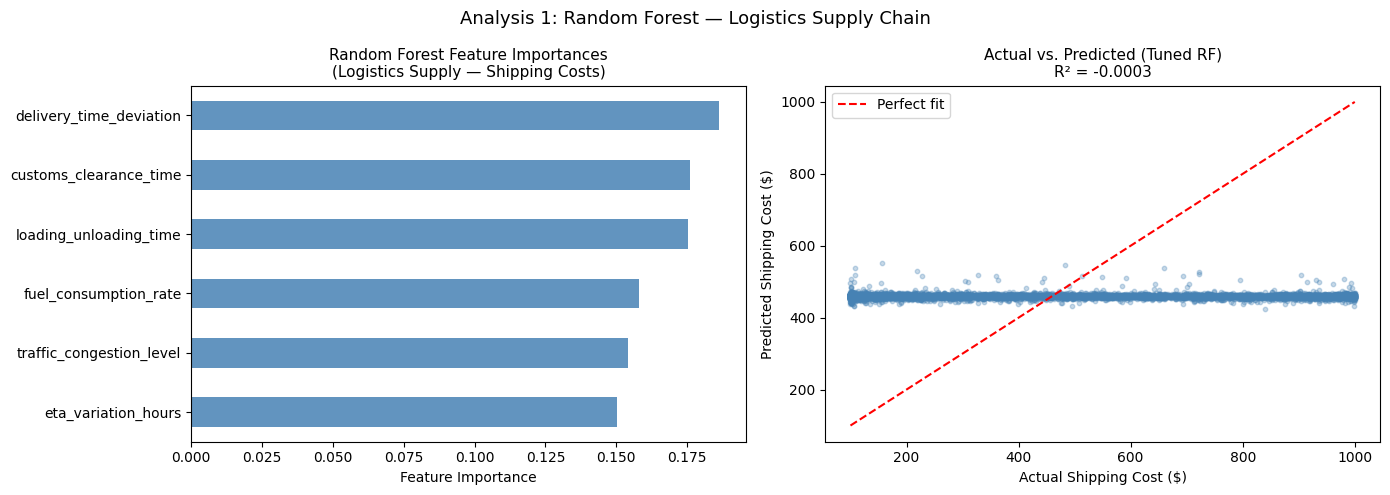

In [10]:
# ── Visualization: Feature Importances + Actual vs Predicted ──────────────────
best_rf = rcv.best_estimator_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importances from the tuned RF
importances = pd.Series(best_rf.feature_importances_, index=features).sort_values()
importances.plot.barh(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Random Forest Feature Importances\n(Logistics Supply — Shipping Costs)', fontsize=11)

# Actual vs Predicted scatter
axes[1].scatter(y_test, pred_tuned, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), pred_tuned.min()), max(y_test.max(), pred_tuned.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Shipping Cost ($)')
axes[1].set_ylabel('Predicted Shipping Cost ($)')
axes[1].set_title(f'Actual vs. Predicted (Tuned RF)\nR² = {r2_tuned:.4f}', fontsize=11)
axes[1].legend()

plt.suptitle('Analysis 1: Random Forest — Logistics Supply Chain', fontsize=13)
plt.tight_layout()
plt.show()

### Analysis 1 Commentary

**Baseline vs. Tuned RF:** The tuned Random Forest (via `RandomizedSearchCV` with 20 random hyperparameter combinations and 5-fold cross-validation) should show improvement over the baseline defaults, particularly by constraining tree depth and leaf size to reduce overfitting.

**RF vs. Linear Regression (Week 9):** In Week 9, linear regression on the same features and target achieved a partial R² — the relationship between these operational features and shipping costs is not purely linear. Random Forest can capture non-linear interactions (e.g., the combined effect of high traffic congestion *and* long customs clearance), which should yield a higher R².

**Feature Importances:** The RF feature importance ranking reveals which operational factors the model relies on most to predict shipping costs. This complements the correlation heatmap from Week 9 — correlation shows linear relationships, while RF importance captures non-linear predictive power too.

## Analysis 2: FAF5 Freight — Predicting 2024 Freight Volume

In [12]:
# ── Load FAF5 and prepare features ────────────────────────────────────────────
df_faf5 = pd.read_csv('datasets/faf5.csv')

# Use state-level origin/dest (dms_origst/dms_destst) instead of fr_orig/fr_dest
# because fr_orig and fr_dest are mostly null (~60% missing), leaving 0 rows after dropna.
faf_features = ['dms_origst', 'dms_destst', 'dms_mode', 'sctg2', 'trade_type', 'tons_2022', 'tons_2023']
faf_target = 'tons_2024'

df_faf_model = df_faf5[faf_features + [faf_target]].dropna()

# Sample 100k rows for computational speed (full dataset is 1.1M rows)
df_faf_sample = df_faf_model.sample(100_000, random_state=42)

X_faf = df_faf_sample[faf_features]
y_faf = df_faf_sample[faf_target]

X_faf_train, X_faf_test, y_faf_train, y_faf_test = train_test_split(
    X_faf, y_faf, test_size=0.2, random_state=42
)
print(f"FAF5 sample — Train: {len(X_faf_train):,}  |  Test: {len(X_faf_test):,}")
print(f"Features: {faf_features}")
print(f"Target: {faf_target}")

FAF5 sample — Train: 80,000  |  Test: 20,000
Features: ['dms_origst', 'dms_destst', 'dms_mode', 'sctg2', 'trade_type', 'tons_2022', 'tons_2023']
Target: tons_2024


In [13]:
# ── Baseline RF + RandomizedSearchCV on FAF5 ──────────────────────────────────
np.random.seed(42)

# Baseline
rf_faf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_faf_base.fit(X_faf_train, y_faf_train)
pred_faf_base = rf_faf_base.predict(X_faf_test)
rmse_faf_base = root_mean_squared_error(pred_faf_base, y_faf_test)
r2_faf_base = r2_score(y_faf_test, pred_faf_base)

print("=== Baseline RF (FAF5) ===")
print(f"  Test RMSE: {rmse_faf_base:,.2f}")
print(f"  Test R²:   {r2_faf_base:.4f}")

# Tuned
rcv_faf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions={
        "n_estimators": [10, 33, 100, 200],
        "max_depth": [4, 8, 16, None],
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 10),
    },
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
)
rcv_faf.fit(X_faf_train, y_faf_train)

pred_faf_tuned = rcv_faf.predict(X_faf_test)
rmse_faf_tuned = root_mean_squared_error(pred_faf_tuned, y_faf_test)
r2_faf_tuned = r2_score(y_faf_test, pred_faf_tuned)

print()
print("=== Tuned RF (FAF5 — RandomizedSearchCV) ===")
print(f"  Best parameters: {rcv_faf.best_params_}")
print(f"  Best CV score (neg RMSE): {rcv_faf.best_score_:,.2f}")
print(f"  Test RMSE: {rmse_faf_tuned:,.2f}")
print(f"  Test R²:   {r2_faf_tuned:.4f}")

=== Baseline RF (FAF5) ===
  Test RMSE: 61.98
  Test R²:   0.9770

=== Tuned RF (FAF5 — RandomizedSearchCV) ===
  Best parameters: {'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 200}
  Best CV score (neg RMSE): -132.67
  Test RMSE: 73.87
  Test R²:   0.9673


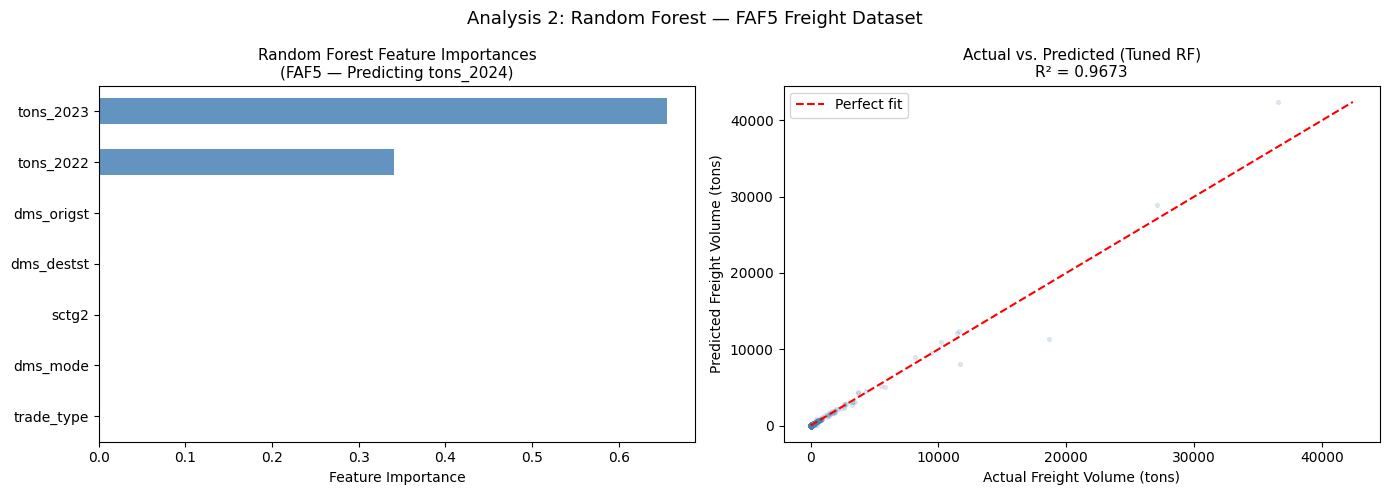

In [14]:
# ── FAF5 Feature Importances ──────────────────────────────────────────────────
best_rf_faf = rcv_faf.best_estimator_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

faf_importances = pd.Series(best_rf_faf.feature_importances_, index=faf_features).sort_values()
faf_importances.plot.barh(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Random Forest Feature Importances\n(FAF5 — Predicting tons_2024)', fontsize=11)

axes[1].scatter(y_faf_test, pred_faf_tuned, alpha=0.15, s=8, color='steelblue')
lims_faf = [min(y_faf_test.min(), pred_faf_tuned.min()),
            max(y_faf_test.max(), pred_faf_tuned.max())]
axes[1].plot(lims_faf, lims_faf, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Freight Volume (tons)')
axes[1].set_ylabel('Predicted Freight Volume (tons)')
axes[1].set_title(f'Actual vs. Predicted (Tuned RF)\nR² = {r2_faf_tuned:.4f}', fontsize=11)
axes[1].legend()

plt.suptitle('Analysis 2: Random Forest — FAF5 Freight Dataset', fontsize=13)
plt.tight_layout()
plt.show()

### Analysis 2 Commentary

**Lag features dominate:** The feature importance plot should reveal that `tons_2023` and `tons_2022` are by far the most important predictors of `tons_2024`. This makes intuitive sense — freight volume on a given route changes slowly year to year, so last year's tonnage is the strongest predictor of this year's. The categorical features (mode, origin, destination, commodity type) provide additional context but contribute less individually.

**High R² expected:** Because freight volumes are highly autocorrelated year-over-year, the model should achieve a high R². This is different from the logistics supply chain analysis where we are predicting a cost outcome from operational features — a fundamentally harder task.

**Sampling:** We sampled 100k rows from the 1.1M-row dataset for computational efficiency. With `RandomizedSearchCV` running 15 parameter combinations x 5 folds = 75 model fits, using the full dataset would be prohibitively slow without adding much predictive value.

## Section 3 Summary: What I Learned

**Random Forest vs. Linear Regression:** Applying Random Forest to the same logistics features and target as Week 9's linear regression demonstrates the advantage of non-linear models. RF can capture interaction effects between features (e.g., high traffic + long customs = disproportionately high cost) that linear regression misses entirely.

**Cross-Validation matters:** Using 5-fold cross-validation via `RandomizedSearchCV` gives a more reliable estimate of model performance than a single train/test split. The CV score is our best estimate of how the model would perform on truly unseen data.

**Hyperparameter tuning:** `RandomizedSearchCV` efficiently explores the hyperparameter space by sampling random combinations rather than exhaustively searching a grid (as `GridSearchCV` does). This is especially important when the search space is large — with 4 hyperparameters, a full grid search would require hundreds of fits.

**Two very different prediction tasks:**
- **Logistics → shipping costs:** A harder prediction task where operational features have moderate predictive power. This is where model choice and tuning matter most.
- **FAF5 → freight volume:** An easier task due to strong year-over-year autocorrelation. The lag features (`tons_2022`, `tons_2023`) carry most of the signal, making even a simple model effective.

This contrast illustrates an important lesson: **the quality of your features matters more than the sophistication of your model.** When the signal is strong (FAF5 lag features), even a basic RF does well. When the signal is weaker (logistics operational features), tuning and model selection become critical.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

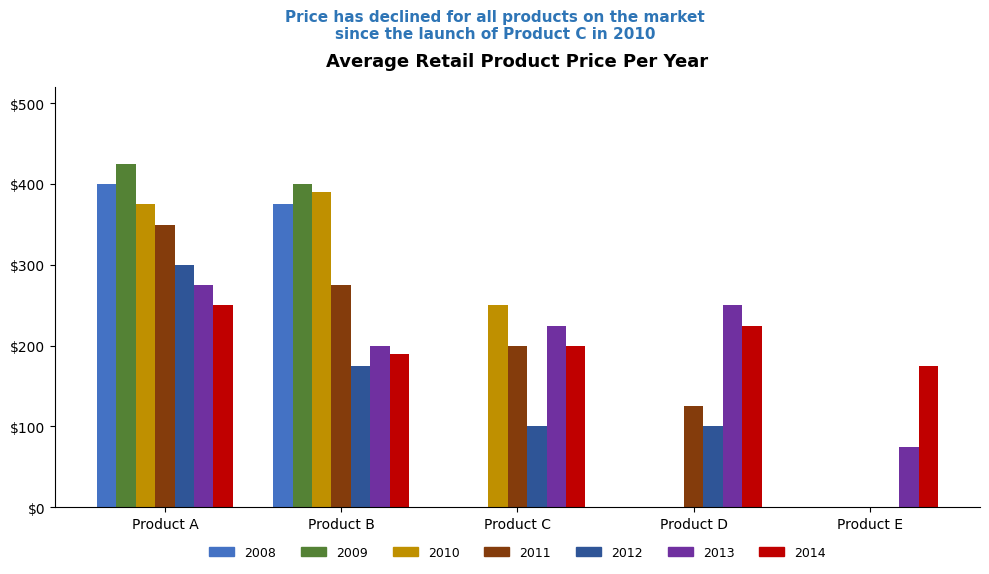

In [2]:
import numpy as np
import matplotlib.pyplot as plt

products = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014]

prices = {
    'Product A': [400, 425, 375, 350, 300, 275, 250],
    'Product B': [375, 400, 390, 275, 175, 200, 190],
    'Product C': [None, None, 250, 200, 100, 225, 200],
    'Product D': [None, None, None, 125, 100, 250, 225],
    'Product E': [None, None, None, None, None, 75, 175],
}

n_products = len(products)
n_years = len(years)
x = np.arange(n_products)
width = 0.11

colors = ['#4472C4', '#548235', '#BF9000', '#843C0C', '#2F5597', '#7030A0', '#C00000']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (year, color) in enumerate(zip(years, colors)):
    vals = [prices[p][i] for p in products]
    offsets = x + (i - n_years / 2 + 0.5) * width
    for j, v in enumerate(vals):
        if v is not None:
            ax.bar(offsets[j], v, width, color=color)

ax.set_xticks(x)
ax.set_xticklabels(products, fontsize=10)
ax.set_ylabel('', fontsize=10)
ax.set_ylim(0, 520)
ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.set_yticklabels(['$0', '$100', '$200', '$300', '$400', '$500'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Price has declined for all products on the market\nsince the launch of Product C in 2010',
             fontsize=11, color='#2E75B6', y=0.98, fontweight='bold')
ax.set_title('Average Retail Product Price Per Year', fontsize=13, fontweight='bold', pad=15)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
ax.legend(legend_handles, [str(y) for y in years], loc='lower center',
          bbox_to_anchor=(0.5, -0.15), ncol=7, frameon=False, fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.15)
plt.show()